In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv("scraped_electronics_dataset.csv")
df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)
print(df.shape)

(114, 6)


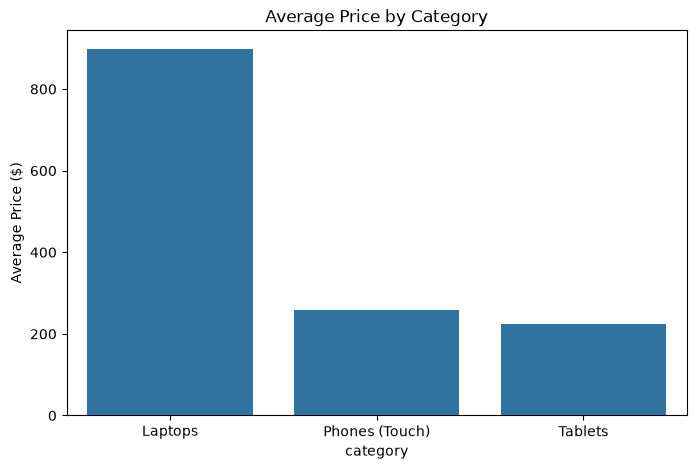

In [3]:
avg_price_by_category = df.groupby('category')['price'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=avg_price_by_category.index, y=avg_price_by_category.values)
plt.title("Average Price by Category")
plt.ylabel("Average Price ($)")
plt.show()

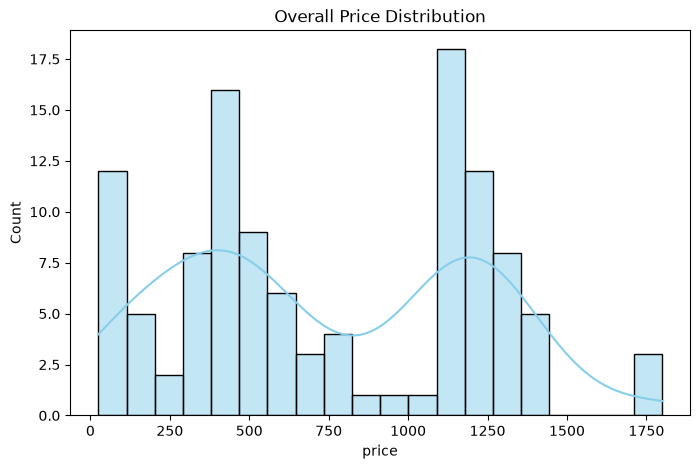

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=20, kde=True, color="skyblue")
plt.title("Overall Price Distribution")
plt.show()

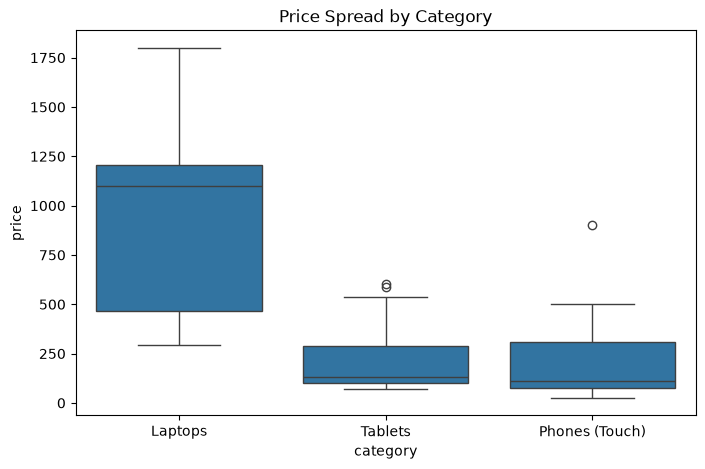

In [5]:
plt.figure(figsize=(8,5))
sns.boxplot(x='category', y='price', data=df)
plt.title("Price Spread by Category")
plt.show()

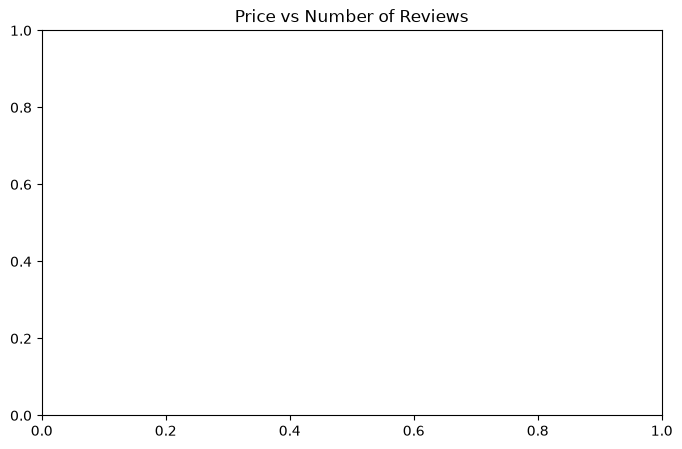

In [6]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='reviews', y='price', hue='category', data=df)
plt.title("Price vs Number of Reviews")
plt.show()

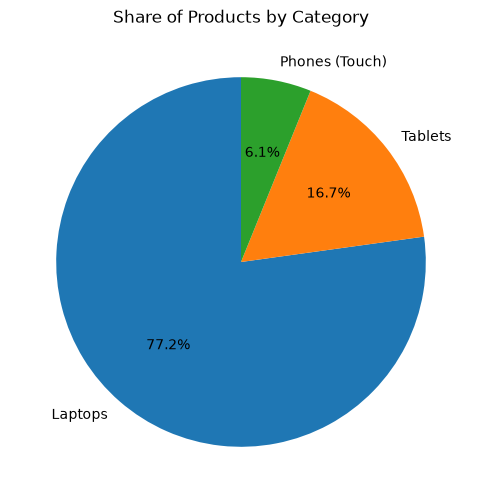

In [7]:
category_counts = df['category'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Share of Products by Category")
plt.show()

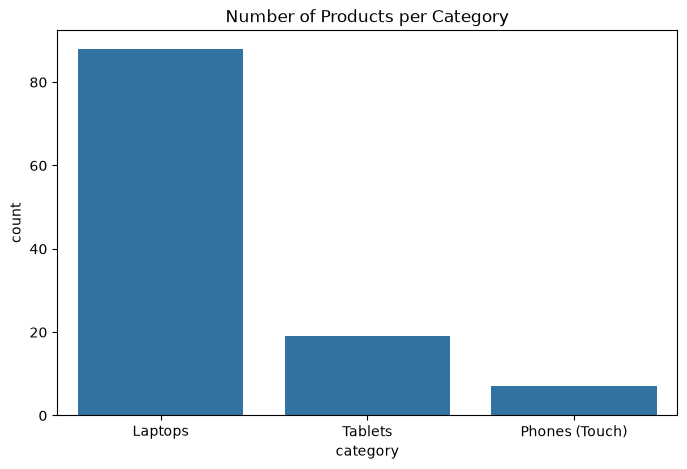

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(x='category', data=df)
plt.title("Number of Products per Category")
plt.show()

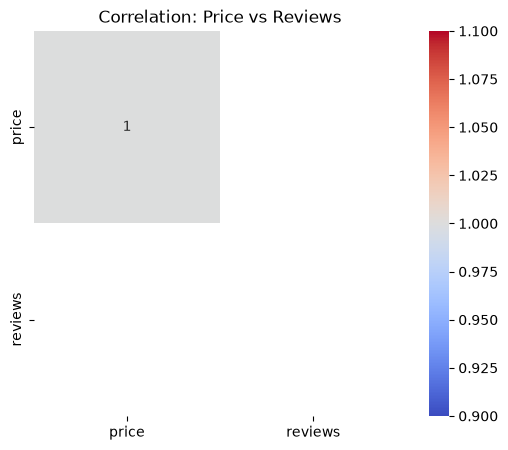

In [9]:
plt.figure(figsize=(6,5))
corr = df[['price', 'reviews']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation: Price vs Reviews")
plt.show()

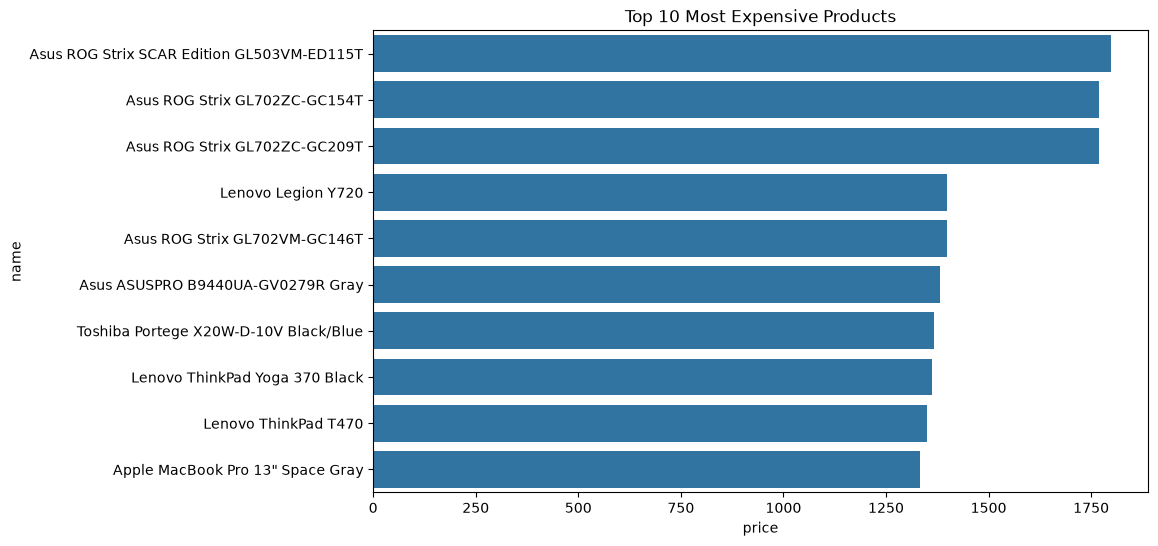

In [10]:
top10 = df.sort_values('price', ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x='price', y='name', data=top10)
plt.title("Top 10 Most Expensive Products")
plt.show()

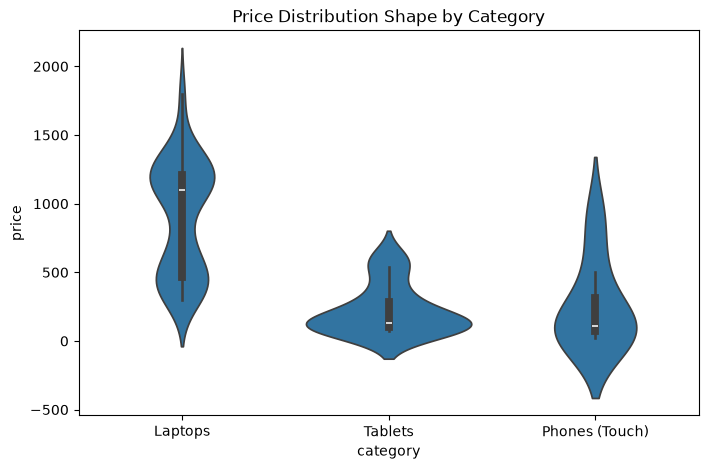

In [11]:
plt.figure(figsize=(8,5))
sns.violinplot(x='category', y='price', data=df)
plt.title("Price Distribution Shape by Category")
plt.show()

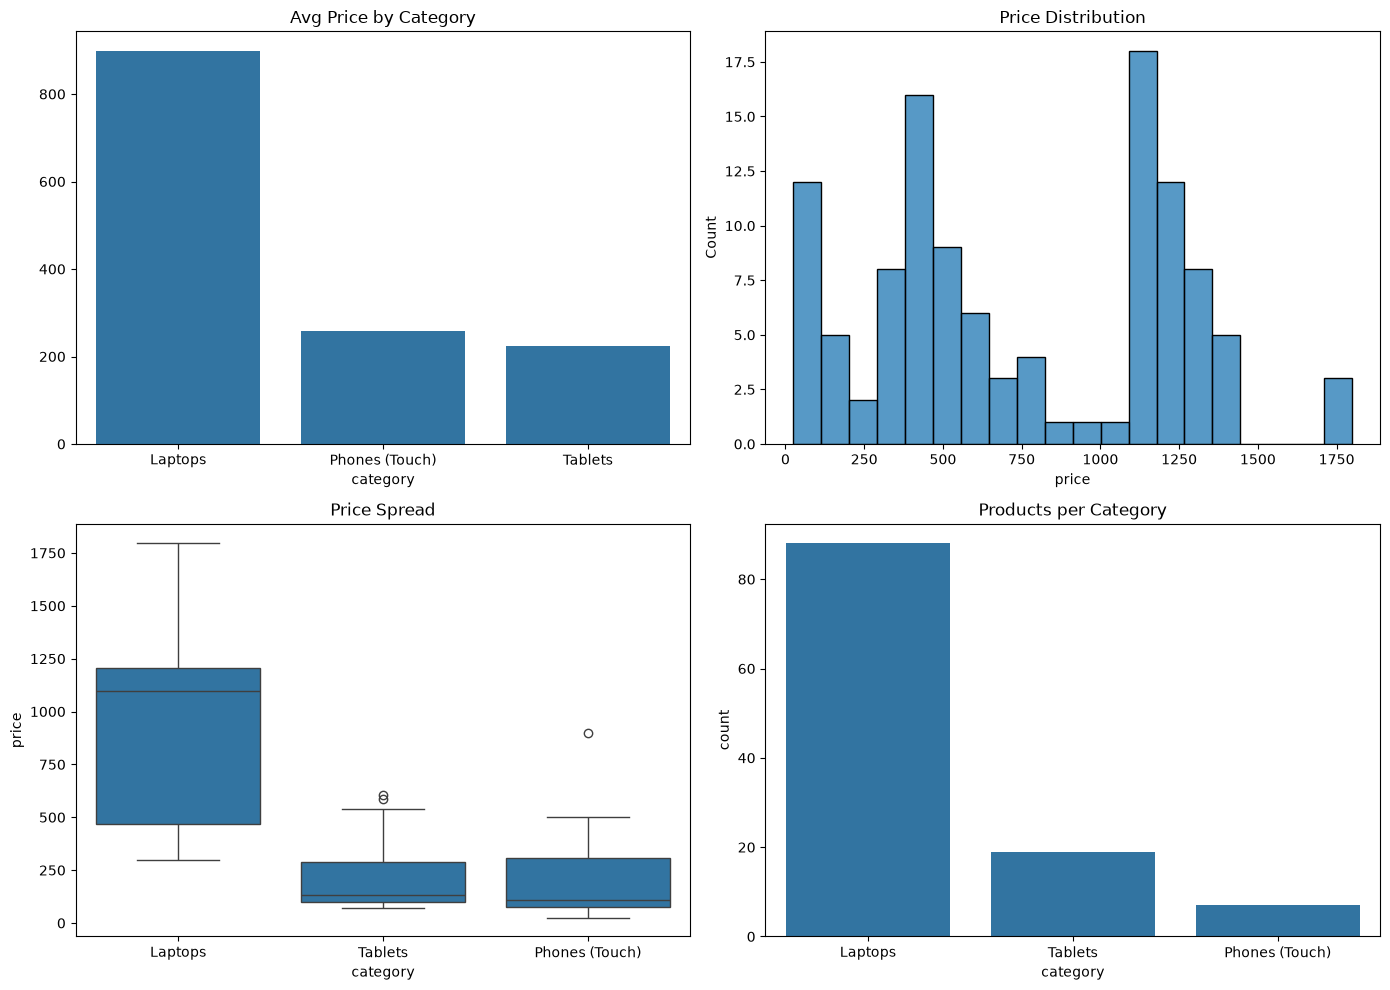

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))
sns.barplot(x=avg_price_by_category.index, y=avg_price_by_category.values, ax=axes[0,0])
axes[0,0].set_title("Avg Price by Category")
sns.histplot(df['price'], bins=20, ax=axes[0,1])
axes[0,1].set_title("Price Distribution")
sns.boxplot(x='category', y='price', data=df, ax=axes[1,0])
axes[1,0].set_title("Price Spread")
sns.countplot(x='category', data=df, ax=axes[1,1])
axes[1,1].set_title("Products per Category")
plt.tight_layout()
plt.show()

In [13]:
fig.savefig("dashboard_summary.png")
print("Dashboard saved as dashboard_summary.png")

Dashboard saved as dashboard_summary.png


In [14]:
print("Visual Insights")
print(f"1. Most expensive category on average: {avg_price_by_category.idxmax()}")
print(f"2. Cheapest category on average: {avg_price_by_category.idxmin()}")
print(f"3. Category with most listings: {category_counts.idxmax()}")
print(f"4. Correlation between price and reviews: {corr.iloc[0,1]:.2f}")

Visual Insights
1. Most expensive category on average: Laptops
2. Cheapest category on average: Tablets
3. Category with most listings: Laptops
4. Correlation between price and reviews: nan


In [15]:
print("Task 3 Summary")
print(f"Total products visualized: {len(df)}")
print(f"Categories covered: {list(df['category'].unique())}")
print("Charts created: bar, histogram, boxplot, scatter, pie, countplot, heatmap, top-10 bar, violin, and a 4-panel dashboard")

Task 3 Summary
Total products visualized: 114
Categories covered: ['Laptops', 'Tablets', 'Phones (Touch)']
Charts created: bar, histogram, boxplot, scatter, pie, countplot, heatmap, top-10 bar, violin, and a 4-panel dashboard
